Epoch [1/100], Loss: 14973.80
Epoch [2/100], Loss: 7382.42
Epoch [3/100], Loss: 5835.84
Epoch [4/100], Loss: 5383.62
Epoch [5/100], Loss: 4909.42
Epoch [6/100], Loss: 4545.24
Epoch [7/100], Loss: 4189.32
Epoch [8/100], Loss: 3949.79
Epoch [9/100], Loss: 3853.66
Epoch [10/100], Loss: 3815.71
Epoch [11/100], Loss: 3808.81
Epoch [12/100], Loss: 3780.24
Epoch [13/100], Loss: 3780.60
Epoch [14/100], Loss: 3755.11
Epoch [15/100], Loss: 3756.01
Epoch [16/100], Loss: 3750.97
Epoch [17/100], Loss: 3732.04
Epoch [18/100], Loss: 3724.45
Epoch [19/100], Loss: 3742.61
Epoch [20/100], Loss: 3714.33
Epoch [21/100], Loss: 3694.70
Epoch [22/100], Loss: 3694.46
Epoch [23/100], Loss: 3700.83
Epoch [24/100], Loss: 3679.56
Epoch [25/100], Loss: 3696.58
Epoch [26/100], Loss: 3673.20
Epoch [27/100], Loss: 3681.77
Epoch [28/100], Loss: 3645.88
Epoch [29/100], Loss: 3651.67
Epoch [30/100], Loss: 3650.26
Epoch [31/100], Loss: 3662.05
Epoch [32/100], Loss: 3629.38
Epoch [33/100], Loss: 3636.23
Epoch [34/100], Lo

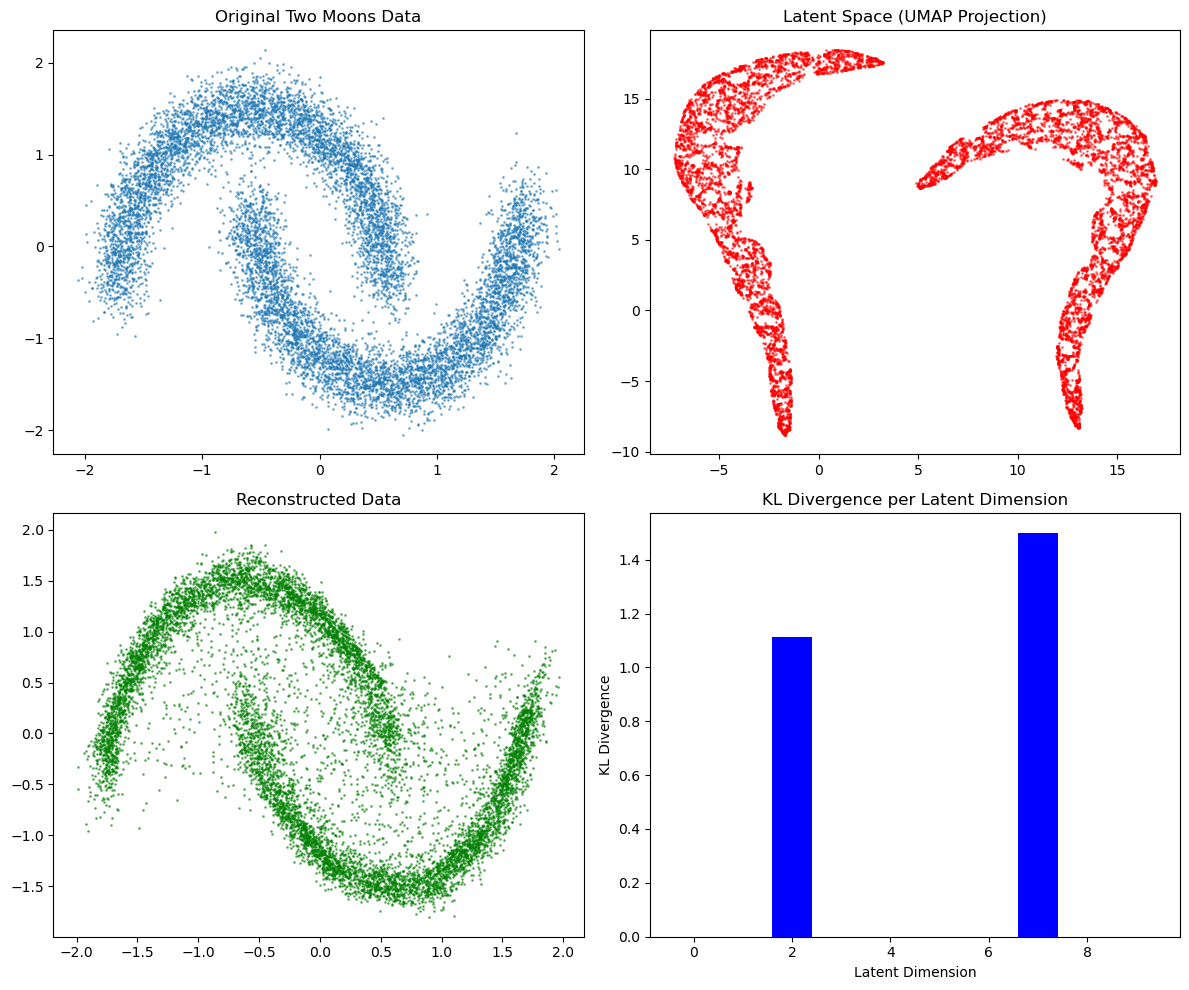

KL 散度均值（Two Moons）: 0.26120502
KL 散度向量: [4.6823934e-05 3.9045248e-04 1.1129270e+00 8.7912864e-05 6.1811996e-05
 5.8222005e-05 7.4173586e-05 1.4981307e+00 7.1755465e-05 2.0175651e-04]


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import umap  # 新增 UMAP
from sklearn.datasets import make_moons
from torch.utils.data import DataLoader, TensorDataset

# 生成 Two Moons 数据
X, _ = make_moons(n_samples=10000, noise=0.1)
X = (X - X.mean(axis=0)) / X.std(axis=0)  # 归一化处理
X = torch.tensor(X, dtype=torch.float32)

# 转换为 DataLoader
dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# 定义 VAE
class VAE(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=32, latent_dim=10):  # 增加潜在空间维度
        super(VAE, self).__init__()
        # 编码器
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc3_logvar = nn.Linear(hidden_dim, latent_dim)

        # 解码器
        self.fc4 = nn.Linear(latent_dim, hidden_dim)
        self.fc5 = nn.Linear(hidden_dim, hidden_dim)
        self.fc6 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))
        mu = self.fc3_mu(h)
        logvar = self.fc3_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc4(z))
        h = F.relu(self.fc5(h))
        return self.fc6(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# 设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 训练 VAE
latent_dim = 10  # 增加潜在空间维度
vae = VAE(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(vae.parameters(), lr=0.001)
num_epochs = 100
beta = 0.1  # 使用 β-VAE

vae.train()
for epoch in range(num_epochs):
    total_loss = 0
    for batch in dataloader:
        x = batch[0].to(device)
        optimizer.zero_grad()
        recon_x, mu, logvar = vae(x)

        # 计算损失：重构误差 + β * KL 散度
        recon_loss = F.mse_loss(recon_x, x, reduction="sum")
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + beta * kl_loss

        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss:.2f}")

# 评估 VAE
vae.eval()
with torch.no_grad():
    mu, logvar = vae.encode(X.to(device))
    z = vae.reparameterize(mu, logvar)
    recon_X = vae.decode(z).cpu().numpy()
    KL = 0.5 * (-logvar + torch.exp(logvar) + mu**2 - 1)
    KL_values = KL.mean(dim=0).cpu().numpy()
    mu = mu.cpu().numpy()

# 使用 UMAP 将潜空间降维到 2D
umap_model = umap.UMAP(n_neighbors=50, min_dist=0.1, metric='euclidean')
z_umap = umap_model.fit_transform(mu)

# 可视化
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

# 原始数据
ax[0, 0].scatter(X[:, 0], X[:, 1], s=1, alpha=0.5)
ax[0, 0].set_title("Original Two Moons Data")

# 🔹 使用 UMAP 绘制潜在空间
ax[0, 1].scatter(z_umap[:, 0], z_umap[:, 1], s=1, alpha=0.5, color="red")
ax[0, 1].set_title("Latent Space (UMAP Projection)")

# 重构数据
ax[1, 0].scatter(recon_X[:, 0], recon_X[:, 1], s=1, alpha=0.5, color="green")
ax[1, 0].set_title("Reconstructed Data")

# KL 散度（10 维度）
ax[1, 1].bar(range(len(KL_values)), KL_values, color="blue")
ax[1, 1].set_xlabel("Latent Dimension")
ax[1, 1].set_ylabel("KL Divergence")
ax[1, 1].set_title("KL Divergence per Latent Dimension")

plt.tight_layout()
plt.show()

print("KL 散度均值（Two Moons）:", KL_values.mean())
print("KL 散度向量:", KL_values)
